In [88]:
%load_ext autoreload
%autoreload 2

import sys
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

import pygenelab as pgl
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import scanpy as sc

# Append the src directory to the path
current_dir = os.getcwd()
src_dir = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_dir not in sys.path:
    sys.path.append(src_dir)

working_dir = "/ix/djishnu/Akanksha/datasets/SKM_multimodal_ageing"

In [90]:
human_adata = '/ix/djishnu/Akanksha/datasets/SKM_multimodal_ageing/objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad'
adata = sc.read_h5ad(human_adata)

In [91]:
adata.obs['age'].value_counts()

age
80    2000
34    1989
Name: count, dtype: int64

In [92]:
adata.obs['Annotation'].value_counts()

Annotation
Type II        3391
ENOX1+ (II)     350
ID1+ (II)       241
DCLK1+ (II)       4
SAA2+ (II)        2
TNNT2+ (II)       1
Name: count, dtype: int64

In [93]:
adata

AnnData object with n_obs × n_vars = 3989 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'score_aucell'
    varm: 'PCs'
    layers: 'counts', 'counts_float', 'lognorm'
    obsp: 'connectivities', 'distances'

#### Sparsity based gene filtering

In [94]:
import numpy as np
from scipy.sparse import issparse

def calculate_zero_proportion(adata, axis='genes'):
    """
    Calculate the proportion of zeros for either genes (features) or cells in an AnnData object.
    
    Parameters:
    -----------
    adata : AnnData
        The AnnData object containing gene expression data
    axis : str, default 'genes'
        Which axis to calculate zeros for:
        - 'genes' or 'features' or 'columns': calculate zeros per gene (column-wise)
        - 'cells' or 'rows': calculate zeros per cell (row-wise)
        
    Returns:
    --------
    proportion_zeros : numpy.ndarray
        Array containing the proportion of zeros for each gene or cell
    """
    if axis.lower() in ['genes', 'features', 'columns']:
        # Calculate zeros per gene (column-wise)
        if issparse(adata.X):
            # For sparse matrix: count non-zeros, then calculate zeros
            n_cells = adata.n_obs
            non_zero_per_gene = np.array((adata.X != 0).sum(axis=0)).flatten()
            zero_per_gene = n_cells - non_zero_per_gene
            proportion_zeros = zero_per_gene / n_cells
        else:
            # For dense matrix
            proportion_zeros = (adata.X == 0).sum(axis=0) / adata.n_obs
            
    elif axis.lower() in ['cells', 'rows']:
        # Calculate zeros per cell (row-wise)
        if issparse(adata.X):
            # For sparse matrix: count non-zeros, then calculate zeros
            n_genes = adata.n_vars
            non_zero_per_cell = np.array((adata.X != 0).sum(axis=1)).flatten()
            zero_per_cell = n_genes - non_zero_per_cell
            proportion_zeros = zero_per_cell / n_genes
        else:
            # For dense matrix
            proportion_zeros = (adata.X == 0).sum(axis=1) / adata.n_vars
    else:
        raise ValueError("axis must be 'genes', 'features', 'columns', 'cells', or 'rows'")
    
    return proportion_zeros

def plot_sparsity_analysis(proportion_zeros, str='features', figsize=(14, 5), bins=50, 
                                color='steelblue', alpha=0.7, show_stats=True):
    """
    Plot cell/feature sparsity analysis with histogram and cumulative distribution.
    
    Parameters:
    -----------
    proportion_zeros : numpy.ndarray
        Array containing the proportion of zeros for each feature/cell
    figsize : tuple, default (14, 5)
        Figure size for the plots
    bins : int, default 50
        Number of bins for the histogram
    color : str, default 'steelblue'
        Color for the histogram bars
    alpha : float, default 0.7
        Transparency for the histogram bars
    show_stats : bool, default True
        Whether to print summary statistics
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object
    axes : numpy.ndarray
        Array of axes objects
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Plot 1: Histogram of cell/feature sparsity
    axes[0].hist(proportion_zeros, bins=bins, edgecolor='black', alpha=alpha, color=color)
    axes[0].set_xlabel('Proportion of zeros')
    axes[0].set_ylabel('Number of ' + str)
    axes[0].set_title('Sparsity')
    axes[0].axvline(proportion_zeros.mean(), color='red', linestyle='--', 
                    label=f'Mean = {proportion_zeros.mean():.2f}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot 2: Cumulative distribution
    sorted_props = np.sort(proportion_zeros)
    cumulative = np.arange(1, len(sorted_props) + 1) / len(sorted_props)
    axes[1].plot(sorted_props, cumulative, linewidth=2)
    axes[1].set_xlabel('Proportion of zeros')
    axes[1].set_ylabel('Cumulative fraction of ' + str)
    axes[1].set_title('Cumulative Distribution of Sparsity')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary statistics
    if show_stats:
        print(f"Total {str}: {len(proportion_zeros)}")
        print(f"Mean proportion of zeros: {proportion_zeros.mean():.3f}")
        print(f"Median proportion of zeros: {np.median(proportion_zeros):.3f}")
        print(f"\n{str} by sparsity:")
        print(f"  >95% zeros: {(proportion_zeros > 0.95).sum()} {str} ({(proportion_zeros > 0.95).sum()/len(proportion_zeros)*100:.1f}%)")
        print(f"  >94% zeros: {(proportion_zeros > 0.94).sum()} {str} ({(proportion_zeros > 0.94).sum()/len(proportion_zeros)*100:.1f}%)")
        print(f"  >90% zeros: {(proportion_zeros > 0.90).sum()} {str} ({(proportion_zeros > 0.90).sum()/len(proportion_zeros)*100:.1f}%)")
        print(f"  All zeros:  {(proportion_zeros == 1.0).sum()} {str}")
    
    return fig, axes


In [95]:
proportion_zeros_feature = calculate_zero_proportion(adata, axis='features')

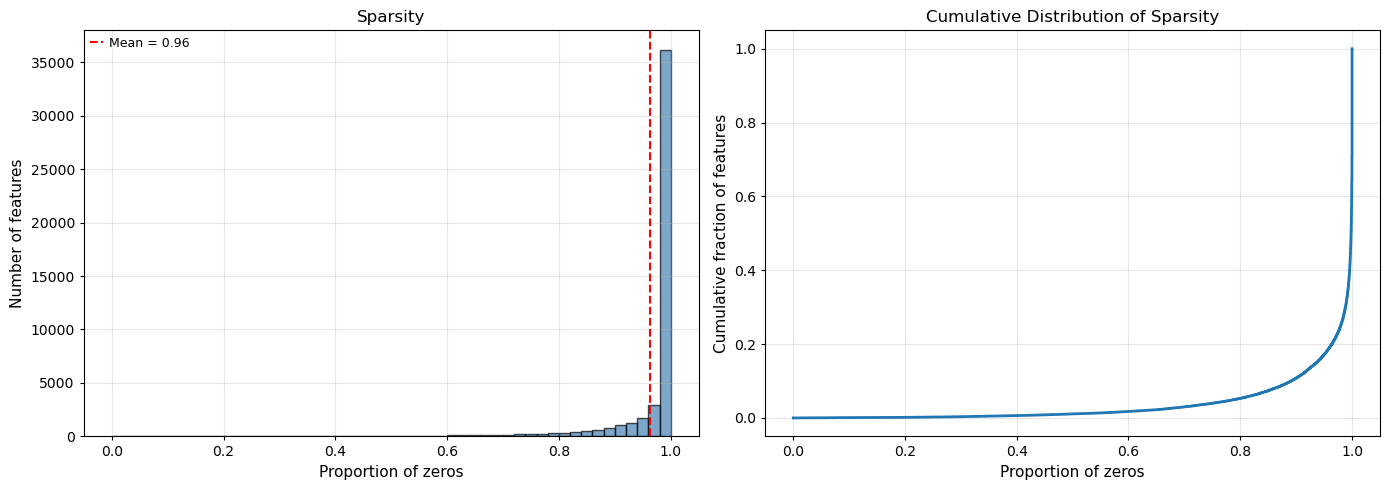

Total features: 48355
Mean proportion of zeros: 0.963
Median proportion of zeros: 0.998

features by sparsity:
  >95% zeros: 40066 features (82.9%)
  >94% zeros: 40858 features (84.5%)
  >90% zeros: 43140 features (89.2%)
  All zeros:  13973 features


In [96]:
# Plot the analysis
fig, axes = plot_sparsity_analysis(proportion_zeros_feature, str='features')

In [97]:
# Remove genes with all zeros
genes_to_keep = proportion_zeros_feature < 0.9

print(f"Before filtering: {adata.n_vars} genes")
adata_filtered = adata[:, genes_to_keep]
print(f"After filtering: {adata_filtered.n_vars} genes")
print(f"Removed: {(~genes_to_keep).sum()} genes")

Before filtering: 48355 genes
After filtering: 5215 genes
Removed: 43140 genes


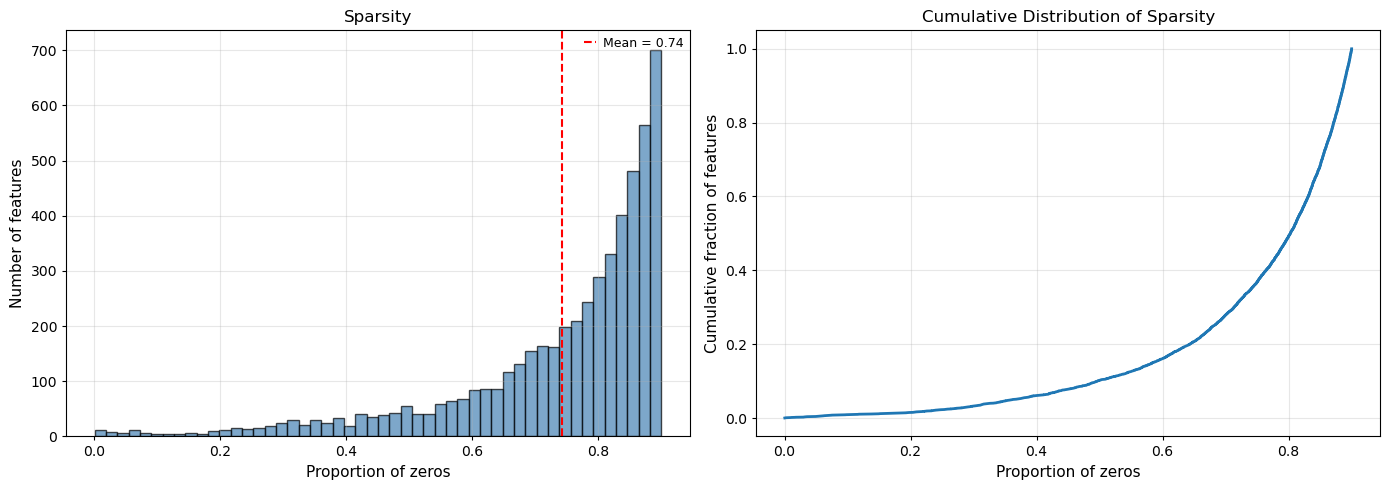

Total features: 5215
Mean proportion of zeros: 0.742
Median proportion of zeros: 0.803

features by sparsity:
  >95% zeros: 0 features (0.0%)
  >94% zeros: 0 features (0.0%)
  >90% zeros: 0 features (0.0%)
  All zeros:  0 features


In [98]:
proportion_zeros_feature = calculate_zero_proportion(adata_filtered, axis='features')
# Plot the analysis
fig, axes = plot_sparsity_analysis(proportion_zeros_feature, str='features')

### Variance based filtering

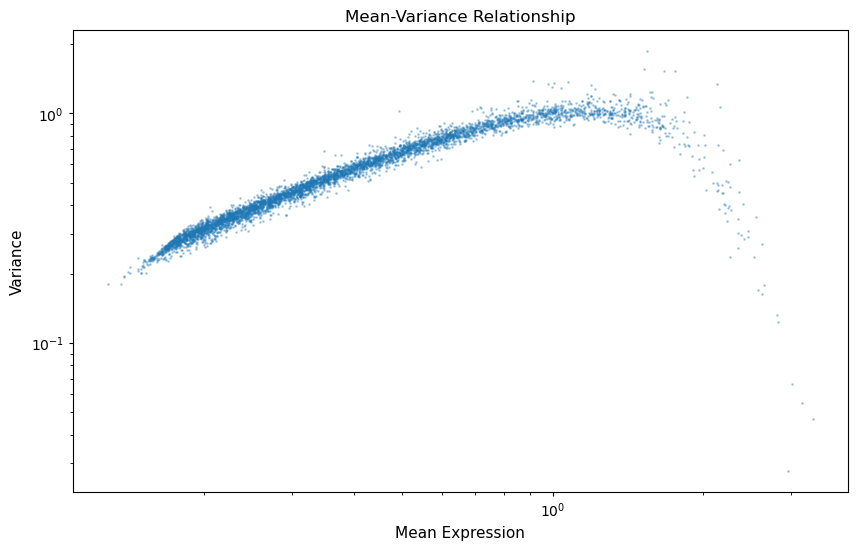

In [99]:
# Calculate mean and variance for each gene
gene_mean = np.mean(adata_filtered.X.toarray() if hasattr(adata_filtered.X, 'toarray') else adata_filtered.X, axis=0)
gene_variance = np.var(adata_filtered.X.toarray() if hasattr(adata_filtered.X, 'toarray') else adata_filtered.X, axis=0)

# Add variance to adata.var for easy access
adata_filtered.var['variance'] = gene_variance

plt.figure(figsize=(10, 6))
plt.scatter(gene_mean, gene_variance, alpha=0.3, s=1)
plt.xlabel('Mean Expression')
plt.ylabel('Variance')
plt.title('Mean-Variance Relationship')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [100]:
adata_df = adata_filtered.to_df()
adata_df

,AL669831.3,MTATP6P1,LINC01128,INTS11,DVL1,CCNL2,MRPL20,ATAD3B,SSU72,MIB2,...,TXLNGY,Z83843.1,SNHG20,WBP1,AC004890.2,AL137127.1,AP000769.5,CSNK2B,AC005495.1,AC105339.2
CELL303_N2_1_1_6_1,0.000000,0.000000,1.796355,1.470937,0.000000,1.791874,0.000000,1.480646,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,1.486078,0.000000,0.000000,0.000000
CELL2900_N1_1_1_6_1,0.000000,0.000000,0.000000,0.000000,0.000000,2.494645,0.000000,2.349542,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,2.061158,0.000000,0.000000,0.000000
CELL2202_N1_1_1_6_1,0.000000,1.597174,0.000000,0.000000,0.000000,1.779781,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
CELL3194_N1_1_1_6_1,0.000000,0.000000,2.032342,0.000000,0.000000,0.000000,0.000000,2.034953,2.017415,0.0,...,0.0,2.028301,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
CELL523_N2_1_1_6_1,0.000000,0.000000,0.000000,1.486220,0.000000,1.478953,0.000000,1.496703,1.452418,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.497899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL1197_N1_1_11_1,0.000000,0.000000,0.000000,0.000000,2.260486,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,2.435014,0.000000
CELL1397_N1_1_11_1,1.652335,0.000000,0.000000,0.000000,0.000000,2.301100,1.951917,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,2.460948,0.000000,2.308254,0.000000,0.000000
CELL350_N1_1_11_1,0.000000,0.000000,1.636584,0.000000,0.000000,0.000000,2.361123,0.000000,0.000000,0.0,...,0.0,0.000000,1.651935,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
CELL1777_N1_1_11_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


In [101]:
# Sort Y by Class
Y_sorted = adata_filtered.obs.sort_values('age', ascending=True)

# Reorder adata_df to match the same order
adata_df_sorted = adata_df.loc[Y_sorted.index]

# Verify the order is synchronized
print("Y sorted:")
display(Y_sorted)
print(f"\nold samples (Class=1): {(Y_sorted['age'] == 80).sum()}")
print(f"young samples (Class=0): {(Y_sorted['age'] == 34).sum()}")

print("\nX matrix sorted:")
display(adata_df_sorted)

# Verify indices match
print(f"\nIndices match: {(Y_sorted.index == adata_df_sorted.index).all()}")

Y sorted:


,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,Pseudotime,Pseudotime_typeI,Pseudotime_typeII,bead_count,age_categorical,GOBP_DNA_DAMAGE_RESPONSE,GOBP_DNA_REPAIR,HALLMARK_DNA_REPAIR,REACTOME_DNA_REPAIR
CELL1174_N1_1_11_1,YM2_3,2021.9610,1142,YM2,0.000000,34,snRNA,Female,China,young_pop,Type II,87.0,NaN,87.0,NaN,34,0.073778,0.067748,0.022195,0.037969
CELL1917_N1_1_11_1,YM2_3,2007.0463,1051,YM2,0.064477,34,snRNA,Female,China,young_pop,Type II,25.0,NaN,25.0,NaN,34,0.056293,0.046716,0.037370,0.040481
CELL1422_N1_1_11_1,YM2_3,2267.8916,1250,YM2,0.000000,34,snRNA,Female,China,young_pop,Type II,53.0,NaN,53.0,NaN,34,0.085704,0.072955,0.022750,0.079580
CELL944_N1_1_11_1,YM2_3,2218.5320,1340,YM2,0.007657,34,snRNA,Female,China,young_pop,ENOX1+ (II),32.0,NaN,32.0,NaN,34,0.065411,0.062887,0.029277,0.058845
CELL1401_N1_1_11_1,YM2_3,2032.9787,1124,YM2,0.009656,34,snRNA,Female,China,young_pop,Type II,78.0,NaN,78.0,NaN,34,0.070470,0.065180,0.036368,0.040593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL523_N2_1_1_6_1,OM6_1,2973.4530,2270,OM6,0.082049,80,snRNA,Female,China,old_pop,Type II,91.0,NaN,91.0,NaN,80,0.095432,0.087379,0.067139,0.062522
CELL3194_N1_1_1_6_1,OM6_1,2387.1073,1284,OM6,0.050262,80,snRNA,Female,China,old_pop,Type II,50.0,NaN,50.0,NaN,80,0.082652,0.062191,0.045380,0.042180
CELL2202_N1_1_1_6_1,OM6_1,2602.6083,1572,OM6,0.019580,80,snRNA,Female,China,old_pop,ID1+ (II),94.0,NaN,94.0,NaN,80,0.077198,0.067654,0.062925,0.067493
CELL2900_N1_1_1_6_1,OM6_1,2202.0882,1248,OM6,0.463730,80,snRNA,Female,China,old_pop,Type II,33.0,NaN,33.0,NaN,80,0.082784,0.067559,0.059456,0.052412



old samples (Class=1): 2000
young samples (Class=0): 1989

X matrix sorted:


,AL669831.3,MTATP6P1,LINC01128,INTS11,DVL1,CCNL2,MRPL20,ATAD3B,SSU72,MIB2,...,TXLNGY,Z83843.1,SNHG20,WBP1,AC004890.2,AL137127.1,AP000769.5,CSNK2B,AC005495.1,AC105339.2
CELL1174_N1_1_11_1,0.000000,0.000000,2.022268,2.024334,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
CELL1917_N1_1_11_1,1.838904,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.00000,0.000000,0.0,0.000000,0.0,0.0,2.145650,0.000000,2.435621,0.000000
CELL1422_N1_1_11_1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,2.42587,0.000000,0.0,0.000000,0.0,0.0,1.980994,0.000000,1.974884,0.000000
CELL944_N1_1_11_1,0.000000,0.000000,1.893238,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.00000,0.000000,0.0,1.894164,0.0,0.0,0.000000,1.903484,0.000000,0.000000
CELL1401_N1_1_11_1,0.000000,0.000000,2.050648,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL523_N2_1_1_6_1,0.000000,0.000000,0.000000,1.486220,0.0,1.478953,0.0,1.496703,1.452418,0.0,...,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,1.497899
CELL3194_N1_1_1_6_1,0.000000,0.000000,2.032342,0.000000,0.0,0.000000,0.0,2.034953,2.017415,0.0,...,0.00000,2.028301,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
CELL2202_N1_1_1_6_1,0.000000,1.597174,0.000000,0.000000,0.0,1.779781,0.0,0.000000,0.000000,0.0,...,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
CELL2900_N1_1_1_6_1,0.000000,0.000000,0.000000,0.000000,0.0,2.494645,0.0,2.349542,0.000000,0.0,...,0.00000,0.000000,0.0,0.000000,0.0,0.0,2.061158,0.000000,0.000000,0.000000



Indices match: True


In [102]:
# Update the original variables
Y = Y_sorted['age']
adata_df = adata_df_sorted

In [103]:
display(Y)

CELL1174_N1_1_11_1     34
CELL1917_N1_1_11_1     34
CELL1422_N1_1_11_1     34
CELL944_N1_1_11_1      34
CELL1401_N1_1_11_1     34
                       ..
CELL523_N2_1_1_6_1     80
CELL3194_N1_1_1_6_1    80
CELL2202_N1_1_1_6_1    80
CELL2900_N1_1_1_6_1    80
CELL303_N2_1_1_6_1     80
Name: age, Length: 3989, dtype: int32

In [104]:
#save to csv
out_dir = "/ix/djishnu/Akanksha/datasets/SKM_multimodal_ageing"
adata_df.to_csv(os.path.join(out_dir, 'female_type2_human_X.csv'))

In [105]:
# save to csv
Y.to_csv(os.path.join(out_dir, 'female_type2_human_Y.csv'))

#### Scoring the cells using Z12

In [106]:
# ============================================================
# Transfer learning: project HUMAN cells onto MOUSE SLIDE latent factors
# ------------------------------------------------------------
# Reuse the A-loadings (and C, Gamma) learnt by SLIDE / Essential Regression on
# MOUSE fast-2b/2x metacells (ERCC1-KO: WT=0 vs KO=1) and score human single
# cells with them via predZ -- the cross-prediction the R script does, plus a
# mouse->human ortholog translation so the gene axes line up. No decoupler /
# AUCell: scores come straight from the model A-loadings, as requested.
#
# predZ (EssReg):  Z = X . Gamma^-1 . A . pinv(A^T Gamma^-1 A + C^-1)
#   X must be column-standardized exactly like SLIDE's calcZMatrix: scale(x,T,T).
# ============================================================
import os, sys
# rpy2 must use the conda-env R it was built against; system R 4.5 has an ABI
# mismatch (undefined symbol R_typeToChar). Set R_HOME BEFORE importing rpy2.
os.environ["R_HOME"] = os.path.join(sys.prefix, "lib", "R")

import numpy as np
import rpy2.robjects as ro

# --- paths (mouse model = female_0.1_spec / 0.01_1_out) ------
MODEL_DIR = "/ix/djishnu/Akanksha/datasets/ERCC1_KO/metacell/slide_outs/optimize_slide/female_0.1_spec/0.01_1_out"
MOUSE_X   = "/ix/djishnu/Akanksha/datasets/ERCC1_KO/metacell/female_fast2b_2x_harmonyv2_X.csv"
MOUSE_Y   = "/ix/djishnu/Akanksha/datasets/ERCC1_KO/metacell/female_fast2b_2x_harmonyv2_Y.csv"
ORTHOLOGS = "/ix/djishnu/Akanksha/datasets/gene_sets/gene_sets/human_mouse_1to1_orthologs.csv"
OUT_DIR   = "/ix/djishnu/Akanksha/datasets/SKM_multimodal_ageing"


def load_slide_model(model_dir):
    """Read AllLatentFactors.rds + SLIDE_LFs.rds with base-R readRDS (via rpy2).
    Returns A (genes x K, mouse-gene rows), C, Gamma, beta, the marginal LFs and
    the interaction table. predZ itself runs in pure numpy afterwards."""
    readRDS  = ro.r["readRDS"]
    rownames = ro.r["rownames"]; colnames = ro.r["colnames"]

    lf = readRDS(os.path.join(model_dir, "AllLatentFactors.rds"))
    A       = np.asarray(lf.rx2("A"))
    genes   = list(rownames(lf.rx2("A")))      # mouse gene symbols (rows of A)
    lfnames = list(colnames(lf.rx2("A")))      # Z1 .. ZK
    C       = np.asarray(lf.rx2("C"))
    Gamma   = np.asarray(lf.rx2("Gamma"))
    beta    = np.asarray(lf.rx2("beta")).ravel()

    sl = readRDS(os.path.join(model_dir, "SLIDE_LFs.rds"))
    marginal = [int(v) for v in np.asarray(sl.rx2("marginal_vals"))]
    inter    = sl.rx2("interaction")
    p1 = [int(v) for v in np.asarray(inter.rx2("p1"))]
    p2 = [int(v) for v in np.asarray(inter.rx2("p2"))]
    return dict(A=A, genes=genes, lfnames=lfnames, C=C, Gamma=Gamma, beta=beta,
                marginal=marginal, inter_p1=p1, inter_p2=p2)


model   = load_slide_model(MODEL_DIR)
A_genes = model["genes"]
print(f"A: {model['A'].shape[0]} mouse genes x {model['A'].shape[1]} latent factors")
print(f"marginal LFs: {['Z%d' % v for v in model['marginal']]}")

# significant LFs exactly as the R cross-prediction script defines them:
#   sig_lfs = unique( marginal_vals  U  interaction$p2 )
sig_lfs = []
for v in model["marginal"] + model["inter_p2"]:
    z = f"Z{v}"
    if z not in sig_lfs:
        sig_lfs.append(z)
print(f"sig_lfs ({len(sig_lfs)}): {sig_lfs}")
assert "Z12" in sig_lfs, "Z12 (the LF of interest) is not among the significant factors!"

2026-06-04 15:39:36 | [INFO] cffi mode is CFFI_MODE.ANY
2026-06-04 15:39:36 | [INFO] R home found: /ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/R
2026-06-04 15:39:36 | [INFO] R library path: /software/rhel9/manual/install/r/4.4.0/lib64/R/lib:/software/rhel9/manual/install/java/jdk-21.0.2/lib:/software/rhel9/manual/install/java/jdk-21.0.2/jre/lib:/software/rhel9/spack/install/linux-rhel9-x86_64/gcc-11.4.1/gcc-12.2.0-wwpdewq774425gjqttcipm4cyi5ihfxe/lib64:/software/rhel9/spack/install/linux-rhel9-x86_64/gcc-11.4.1/gcc-12.2.0-wwpdewq774425gjqttcipm4cyi5ihfxe/lib:/software/rhel9/spack/install/linux-rhel9-x86_64/gcc-11.4.1/zstd-1.5.5-p3ezlwydwada6riicy7lr43czpbob7ob/lib:/software/rhel9/spack/install/linux-rhel9-x86_64/gcc-11.4.1/zlib-ng-2.1.5-g64y7iac3sj76bzqrp2k7ibopecsf7i5/lib:/software/rhel9/spack/install/linux-rhel9-x86_64/gcc-11.4.1/mpc-1.3.1-4jbjyradpsfl2ljrgha6rkalcntcikyr/lib:/software/rhel9/spack/install/linux-rhel9-x86_64/gcc-11.4.1/mpfr-4.2.0-pslz2h57ry2drtgd2qvtzjom2i35v6t

A: 1323 mouse genes x 55 latent factors
marginal LFs: ['Z5', 'Z15', 'Z29', 'Z38', 'Z42', 'Z45', 'Z55']
sig_lfs (15): ['Z5', 'Z15', 'Z29', 'Z38', 'Z42', 'Z45', 'Z55', 'Z46', 'Z33', 'Z27', 'Z54', 'Z36', 'Z8', 'Z12', 'Z1']


In [107]:
# ------------------------------------------------------------
# Mouse -> human ortholog map (1:1 table). The A-loadings live in MOUSE gene
# space; to score human cells we pull each cell's expression of the ORTHOLOG of
# every mouse gene in A. Mouse genes with no 1:1 ortholog -- or whose ortholog is
# absent from the human object -- are zero-filled, exactly like the R script
# zero-fills genes that don't transfer between datasets.
# ------------------------------------------------------------
orth = pd.read_csv(ORTHOLOGS)                  # columns: human, mouse
m2h  = dict(zip(orth["mouse"], orth["human"]))

human_var = set(adata.var_names)               # full human gene universe (lognorm .X)

A_to_human = {}                                # mouse gene in A -> human symbol in adata
for g in A_genes:
    h = m2h.get(g)
    if h is not None and h in human_var:
        A_to_human[g] = h

n_mapped  = sum(g in m2h for g in A_genes)
n_present = len(A_to_human)
print(f"A mouse genes with a 1:1 human ortholog        : {n_mapped}/{len(A_genes)}")
print(f"...and that ortholog present in the human data : {n_present}/{len(A_genes)} "
      f"({100 * n_present / len(A_genes):.1f}%  -> the remainder are zero-filled)")

# Z12 drivers specifically (the LF of interest)
z12_genes   = pd.read_csv(os.path.join(MODEL_DIR, "feature_list_Z12.txt"), sep="\t")
z12_present = [g for g in z12_genes["names"] if g in A_to_human]
print(f"\nZ12 drivers: {len(z12_genes)} mouse genes, {len(z12_present)} transferable to human")
print("  transferred:", [f"{g}->{A_to_human[g]}" for g in z12_present])
print("  dropped    :", [g for g in z12_genes["names"] if g not in A_to_human])

A mouse genes with a 1:1 human ortholog        : 1022/1323
...and that ortholog present in the human data : 1015/1323 (76.7%  -> the remainder are zero-filled)

Z12 drivers: 19 mouse genes, 14 transferable to human
  transferred: ['Pdk4->PDK4', 'Ucp3->UCP3', 'Nrp1->NRP1', 'Commd10->COMMD10', 'Xirp2->XIRP2', 'Kcnq1->KCNQ1', 'Mybph->MYBPH', 'Tnfrsf19->TNFRSF19', 'Cyfip2->CYFIP2', 'Dmd->DMD', 'Npc1->NPC1', 'Tacc2->TACC2', 'Asb4->ASB4', 'Vldlr->VLDLR']
  dropped    : ['Pak7', 'Asap2', 'Nctc1', 'Fndc9', 'Aldh1a1']


In [108]:
# ------------------------------------------------------------
# predZ + alignment helpers (pure numpy).
# ------------------------------------------------------------
def standardize_cols(X):
    """Column z-score == SLIDE's scale(x, TRUE, TRUE). Constant / zero-filled
    columns (sd == 0) become 0 instead of NaN."""
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    Z  = (X - mu) / np.where(sd == 0, 1.0, sd)
    Z[:, sd == 0] = 0.0
    return Z


def predZ(X_std, A, C, Gamma):
    """EssReg predZ:  Z = X Gamma^-1 A pinv(A^T Gamma^-1 A + C^-1)."""
    Gamma = np.where(Gamma == 0, 1e-10, Gamma)
    Gi = np.diag(1.0 / Gamma)
    G  = A.T @ Gi @ A + np.linalg.inv(C)
    return X_std @ Gi @ A @ np.linalg.pinv(G)


def align_mouse_to_A(expr_df, A_genes):
    """expr_df: samples x mouse-genes -> ndarray with columns in A_genes order,
    zero-filling A genes absent from expr_df (R's orig_x[, missing] <- 0)."""
    out = pd.DataFrame(0.0, index=expr_df.index, columns=A_genes)
    shared = [g for g in A_genes if g in expr_df.columns]
    out[shared] = expr_df[shared].values
    return out.values, len(shared)


def align_human_to_A(adata_obj, A_genes, A_to_human):
    """Pull human (lognorm .X) expression into MOUSE-gene columns via orthologs.
    Column j (mouse gene A_genes[j]) = human ortholog expression, else 0."""
    human_syms = [A_to_human.get(g) for g in A_genes]
    needed = sorted({h for h in human_syms if h is not None})
    hexpr = adata_obj[:, needed].to_df()                  # cells x needed human genes
    X = np.zeros((adata_obj.n_obs, len(A_genes)), dtype=float)
    for j, h in enumerate(human_syms):
        if h is not None:
            X[:, j] = hexpr[h].values
    return X, list(adata_obj.obs_names)

In [109]:
# ---- MOUSE (orig) -------------------------------------------------
mouse_x_df = pd.read_csv(MOUSE_X, index_col=0)
mouse_y_df = pd.read_csv(MOUSE_Y, index_col=0)
orig_y = mouse_y_df.iloc[:, 0].loc[mouse_x_df.index].astype(int).values     # 0=WT, 1=KO
orig_X_raw, n_shared_mouse = align_mouse_to_A(mouse_x_df, A_genes)
print(f"mouse metacells: {orig_X_raw.shape[0]} x {orig_X_raw.shape[1]} "
      f"({n_shared_mouse}/{len(A_genes)} A-genes present)")

# ---- HUMAN (new) --------------------------------------------------
new_X_raw, human_cells = align_human_to_A(adata, A_genes, A_to_human)
age = adata.obs["age"].astype(int).values
new_y = (age == age.max()).astype(int)        # old(80)=1, young(34)=0  (KO ~ accelerated aging)
print(f"human cells    : {new_X_raw.shape[0]} x {new_X_raw.shape[1]} "
      f"({len(A_to_human)}/{len(A_genes)} A-genes via orthologs)")
print(f"  old(=1): {(new_y == 1).sum()}   young(=0): {(new_y == 0).sum()}")

mouse metacells: 451 x 1323 (1323/1323 A-genes present)
human cells    : 3989 x 1323 (1015/1323 A-genes via orthologs)
  old(=1): 2000   young(=0): 1989


In [110]:
# ---- project both datasets onto the mouse latent factors ----------
A, C, Gamma = model["A"], model["C"], model["Gamma"]
lfnames = model["lfnames"]

orig_z = pd.DataFrame(predZ(standardize_cols(orig_X_raw), A, C, Gamma),
                      index=mouse_x_df.index, columns=lfnames)
new_z  = pd.DataFrame(predZ(standardize_cols(new_X_raw),  A, C, Gamma),
                      index=human_cells,      columns=lfnames)

# sanity check: mouse predZ should reproduce the stored SLIDE z_matrix exactly
_zst = pd.read_csv(os.path.join(MODEL_DIR, "z_matrix.csv"), index_col=0)
_r = np.corrcoef(orig_z["Z12"].values, _zst.loc[orig_z.index, "Z12"].values)[0, 1]
print(f"mouse Z12 reproducibility vs stored z_matrix.csv: r = {_r:.4f}  (expect ~1.0)")

orig_input = orig_z[sig_lfs]
new_input  = new_z[sig_lfs]

mouse Z12 reproducibility vs stored z_matrix.csv: r = 1.0000  (expect ~1.0)


In [111]:
# ------------------------------------------------------------
# Fit a linear model on the MOUSE latent factors (WT vs KO) and apply it,
# unchanged, to the human latent factors -- the R glm(gaussian) cross-prediction.
# ------------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, roc_curve

lin = LinearRegression().fit(orig_input.values, orig_y)
orig_pred = lin.predict(orig_input.values)
new_pred  = lin.predict(new_input.values)

orig_auc = roc_auc_score(orig_y, orig_pred)
new_auc  = roc_auc_score(new_y,  new_pred)
print(f"MOUSE  (WT vs KO)    self-AUC      : {orig_auc:.4f}")
print(f"HUMAN  (young vs old) transfer-AUC : {new_auc:.4f}")

MOUSE  (WT vs KO)    self-AUC      : 0.9896
HUMAN  (young vs old) transfer-AUC : 0.2611


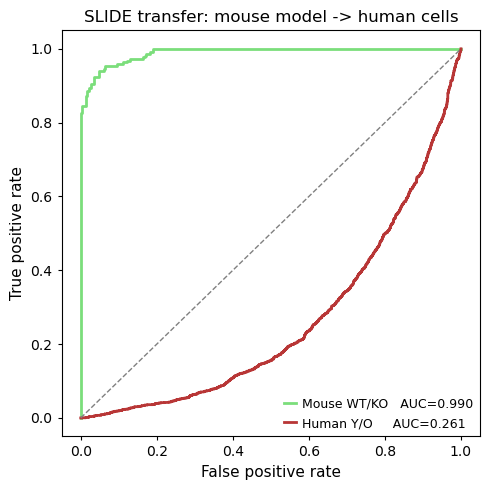

In [112]:
# ---- ROC: mouse self-prediction vs human transfer -----------------
fig, ax = plt.subplots(figsize=(5, 5))
for y_true, y_score, lab, col in [
        (orig_y, orig_pred, f"Mouse WT/KO   AUC={orig_auc:.3f}", "#7BDE7B"),
        (new_y,  new_pred,  f"Human Y/O     AUC={new_auc:.3f}",  "#B83636")]:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, color=col, lw=2, label=lab)
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("SLIDE transfer: mouse model -> human cells")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

##### Per-cell Z12 transferred score
Project each human cell onto **Z12** using the mouse A-loadings (no retraining, no decoupler) and compare young vs old.

2026-06-04 15:42:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-04 15:42:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-04 15:42:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Human Z12 score separates young vs old: AUC = 0.6292


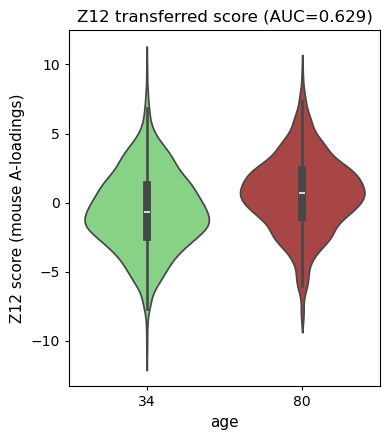

In [113]:
# ------------------------------------------------------------
# Per-cell Z12 activity score on the human cells, straight from the mouse
# A-loadings. Orient so higher score = older if the raw factor points the other
# way (the latent-factor sign is arbitrary).
# ------------------------------------------------------------
adata.obs["Z12_transfer_score"] = new_z["Z12"].reindex(adata.obs_names).values
z12_auc = roc_auc_score(new_y, adata.obs["Z12_transfer_score"].values)
if z12_auc < 0.5:
    adata.obs["Z12_transfer_score"] *= -1
    z12_auc = 1 - z12_auc
print(f"Human Z12 score separates young vs old: AUC = {z12_auc:.4f}")

# plot by age (seaborn stringifies categories -> use string keys / hue)
plot_df = adata.obs[["Z12_transfer_score"]].copy()
plot_df["age"] = adata.obs["age"].astype(str).values
order = [str(a) for a in sorted(adata.obs["age"].astype(int).unique())]
pal = {order[0]: "#7BDE7B", order[1]: "#B83636"}

fig, ax = plt.subplots(figsize=(4, 4.5))
sns.violinplot(data=plot_df, x="age", y="Z12_transfer_score", order=order,
               hue="age", hue_order=order, palette=pal, legend=False,
               inner="box", cut=0, ax=ax)
ax.set_title(f"Z12 transferred score (AUC={z12_auc:.3f})")
ax.set_xlabel("age"); ax.set_ylabel("Z12 score (mouse A-loadings)")
plt.tight_layout(); plt.show()

In [114]:
# ---- save transferred latent factors + Z12 score ------------------
new_z.to_csv(os.path.join(OUT_DIR, "female_type2_human_transferred_Z.csv"))
adata.obs[["age", "Z12_transfer_score"]].to_csv(
    os.path.join(OUT_DIR, "female_type2_human_Z12_score.csv"))
print("saved:")
print("  ", os.path.join(OUT_DIR, "female_type2_human_transferred_Z.csv"))
print("  ", os.path.join(OUT_DIR, "female_type2_human_Z12_score.csv"))

saved:
   /ix/djishnu/Akanksha/datasets/SKM_multimodal_ageing/female_type2_human_transferred_Z.csv
   /ix/djishnu/Akanksha/datasets/SKM_multimodal_ageing/female_type2_human_Z12_score.csv
